칼럼 정보 해석

- team : 팀 데이터
- year(년도), ranking(순위), team(팀명), game(경기 수), win(승리 수), lose(패배 수), draw(무승부 수), winning_rate(승률), games_behind(게임차), 
- recent10(최근 10경기 전적), inarow(연속), home(홈 구장 전적), away(방문 구장 전적)
- 
- pitcher : 투수
- year(년도), name(선수명), team(팀명), era(평균자책점), game_cnt(경기), win(승리 수), lose(패배 수), save(세이브), hold(홀드), wpct(승률), 
- inning(이닝), hit(피안타), home_run(홈런), bb(볼넷), hbp(사구), kk(삼진), r(실점), er(자책점), whip(이닝 당 출루 허용률)
- 
- better_offence : 타자 공격
- year(년도), position(포지션), name(선수명), team(팀명), avg(타율), game_cnt(경기), pa(타석), ab(타수), r(득점), hit(안타), 2b(2루타), 3b(3루타), 
- home_run(홈런), tb(총 루타), rbi(타점), sac(희생번트), sf(희생플라이)
- 
- better_offence2 : 타자 심화
- year(년도), position(포지션), name(선수명), team(팀명), avg(타율), bb(볼넷), ibb(고의사구), hbp(사구), so(삼진), gdp(병살타), slg(장타율), obp(출루율), 
- ops(종합 공격력), mh(한 경기 2안타 이상 경기 수), risp(득점권 타율), ph_ba(대타 타율)
- 
- better_defence : 수비
- year(년도), position(포지션), name(선수명), team(팀명), detail_position(세부 포지션), game(경기 수), gama_starter(선발출전 경기 수), inning_defence(수비이닝), 
- error(실책), pko(견제사), po(풋아웃), assist(도움), double_play(병살), fpct(수비율), pb(포일), sb(도루 허용), cs(도루 저지), cs_pct(도루 저지율)


# 사용할 핵심 데이터 : better_offence2[ops(종합 공격력)], pitcher[era(평균자책점)]

In [20]:
# 데이터 불러오기 / 데이터 프레임 전환

import pandas as pd

team_df = pd.read_csv('data/team.csv', encoding='utf-8')
offence_df = pd.read_csv('data/batter_offence.csv', encoding='utf-8')
offence2_df = pd.read_csv('data/batter_offence2.csv', encoding='utf-8')
pitcher_df = pd.read_csv('data/pitcher.csv', encoding='utf-8')


In [21]:
# 타입 확인 / 결측치 확인

team_df.info()
offence_df.info()
offence2_df.info()
pitcher_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          50 non-null     int64  
 1   ranking       50 non-null     int64  
 2   team          50 non-null     object 
 3   game          50 non-null     int64  
 4   win           50 non-null     int64  
 5   lose          50 non-null     int64  
 6   draw          50 non-null     int64  
 7   winning_rate  50 non-null     float64
 8   games_behind  50 non-null     float64
 9   recent10      50 non-null     object 
 10  inarow        50 non-null     object 
 11  home          50 non-null     object 
 12  away          50 non-null     object 
dtypes: float64(2), int64(6), object(5)
memory usage: 5.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1060 entries, 0 to 1059
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0 

In [22]:
# 데이터 전처리

import pandas as pd

# team_df (문자열 -> 숫자 변환)
team_df['winning_rate'] = pd.to_numeric(team_df['winning_rate'], errors='coerce')
# errors='coerce' : 변환 실패 → NaN 처리

# offence2_df (문자열 -> 숫자 변환)
offence2_df = offence2_df.drop(columns=['Unnamed: 0'])  # 자동 생성 인덱스
offence2_df['ops'] = pd.to_numeric(offence2_df['ops'], errors='coerce')
offence2_df = offence2_df.dropna(subset=['ops'])

cols = ['avg', 'slg', 'obp', 'ops']
for col in cols:
    offence2_df[col] = pd.to_numeric(offence2_df[col], errors='coerce')

# pitcher_df (문자열 -> 숫자 변환)
pitcher_df = pitcher_df.drop(columns=['Unnamed: 0'])

pitcher_df['wpct'] = pd.to_numeric(pitcher_df['wpct'], errors='coerce')

# inning 변환 (중요 데이터)

import pandas as pd

def convert_inning(x):
    if pd.isna(x):
        return 0
    
    x = str(x).strip()
    
    # "173 1/3" 같은 경우
    if ' ' in x:
        parts = x.split(' ')
        whole = int(parts[0])
        
        if '1/3' in parts[1]:
            return whole + 1/3
        elif '2/3' in parts[1]:
            return whole + 2/3
        else:
            return whole
    
    # "123.1" 같은 경우
    try:
        x_float = float(x)
        whole = int(x_float)
        decimal = round(x_float - whole, 1)
        
        if decimal == 0.1:
            return whole + 1/3
        elif decimal == 0.2:
            return whole + 2/3
        else:
            return whole
    
    except:
        return None  # 이상한 값 처리

# apply() : 컬럼의 모든 값에 함수 적용 (괄호 사용 x)
pitcher_df['inning'] = pitcher_df['inning'].apply(convert_inning)

- 왜 apply를 쓰냐?
❌ 안 되는 방법
float('123.1')

👉 그냥 123.1로 처리됨 ❌ (잘못된 값)

-  ✅ 우리가 원하는 건
123.1 → 123 + 1/3
123.2 → 123 + 2/3

👉 그래서 직접 함수 만들어서 하나씩 처리

In [23]:
# 변환 확인
pitcher_df['inning']

0     196.000000
1     173.333333
2     162.000000
3     173.666667
4     166.333333
         ...    
92     11.000000
93     11.000000
94     10.000000
95      9.000000
96      6.000000
Name: inning, Length: 97, dtype: float64

In [30]:
# 팀 단위 데이터 만들기

team_ops = (
    offence2_df.groupby(['year', 'team'])['ops']
    .mean()
    # groupby 결과를 DataFrame으로 변환
    .reset_index(name='team_ops')
)

team_era = (
    pitcher_df.groupby(['year', 'team'])
    .apply(lambda x: (x['er'].sum() * 9) / x['inning'].sum())
    .reset_index(name='team_era')
)

df = team_df.merge(team_ops, on=['year', 'team'])
df = df.merge(team_era, on=['year', 'team'])


df = df[['year', 'team', 'winning_rate', 'team_ops', 'team_era']].dropna()
ops_thresh = df['team_ops'].quantile(0.7)
win_thresh = df['winning_rate'].quantile(0.3)

outliers = df[
    (df['team_ops'] >= ops_thresh) &
    (df['winning_rate'] <= win_thresh)
]


C:\Users\Playdata\AppData\Local\Temp\ipykernel_12908\550725551.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['er'].sum() * 9) / x['inning'].sum())


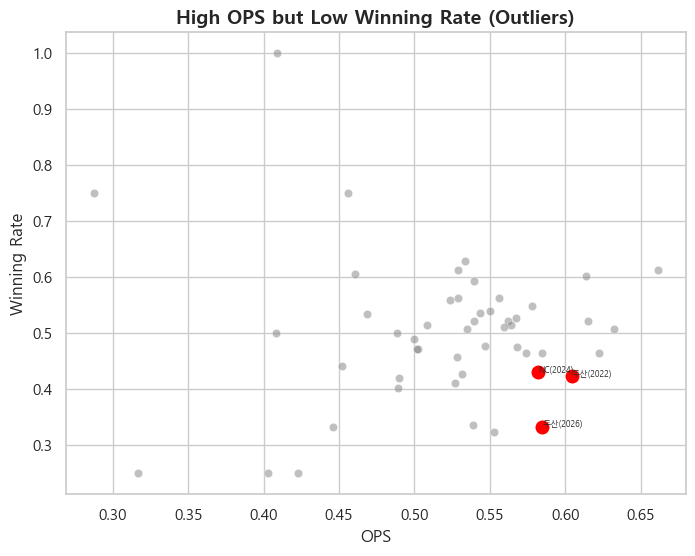

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'   
plt.rcParams['axes.unicode_minus'] = False      

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='team_ops',
    y='winning_rate',
    color='gray',
    alpha=0.5
)

sns.scatterplot(
    data=outliers,
    x='team_ops',
    y='winning_rate',
    color='red',
    s=120
)

# 팀 이름 표시
for i in range(len(outliers)):
    plt.text(
        outliers.iloc[i]['team_ops'],
        outliers.iloc[i]['winning_rate'],
        f"{outliers.iloc[i]['team']}({outliers.iloc[i]['year']})",
    fontsize=6
    )

plt.title('High OPS but Low Winning Rate (Outliers)', fontsize=14, fontweight='bold')
plt.xlabel('OPS')
plt.ylabel('Winning Rate')

plt.show()